# Training Pipeline - Part 2: XGBoost Model Training
## Cyber AI Agent v2.0.0

**Purpose:** Train supervised gradient boosting classifier (Layer 3)

**Inputs:**
- X_train_scaled.pkl
- y_train.pkl
- X_test_scaled.pkl
- y_test.pkl

**Outputs:**
- xgboost_model.pkl (trained model)
- xgboost_metrics.json (performance report)

---

## 1. Load Preprocessed Data

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported")

# Load preprocessed data
X_train = joblib.load('../datasets/X_train_scaled.pkl')
X_test = joblib.load('../datasets/X_test_scaled.pkl')
y_train = joblib.load('../datasets/y_train.pkl')
y_test = joblib.load('../datasets/y_test.pkl')

print(f"\n✅ Data loaded:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")

✅ Libraries imported

✅ Data loaded:
   X_train: (365933, 18)
   X_test: (91484, 18)
   y_train: (365933,)
   y_test: (91484,)


## 2. Train XGBoost Model

In [2]:
print("\n🚀 TRAINING XGBOOST CLASSIFIER")
print("=" * 80)

# Initialize XGBoost with optimized hyperparameters
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',  # Multiclass classification with probabilities
    num_class=5,  # Number of attack types + benign
    max_depth=7,  # Tree depth (balance complexity)
    learning_rate=0.1,  # Learning rate
    n_estimators=100,  # Number of boosting rounds
    subsample=0.8,  # Subsample ratio
    colsample_bytree=0.8,  # Feature subsample ratio
    random_state=42,
    n_jobs=-1,  # Use all cores
    eval_metric='mlogloss'  # Multiclass log loss
)

print(f"\n1. Model Configuration:")
print(f"   Algorithm: XGBoost Gradient Boosting")
print(f"   Max Depth: {xgb_model.max_depth}")
print(f"   Learning Rate: {xgb_model.learning_rate}")
print(f"   N Estimators: {xgb_model.n_estimators}")
print(f"   Classes: 5 (Benign, Brute Force, DDoS, Port Scan, Botnet)")

print(f"\n2. Training on {len(y_train)} samples...")
import time
start_time = time.time()

# Train model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=10
)

training_time = time.time() - start_time
print(f"\n✅ Training complete in {training_time:.2f} seconds")


🚀 TRAINING XGBOOST CLASSIFIER

1. Model Configuration:
   Algorithm: XGBoost Gradient Boosting
   Max Depth: 7
   Learning Rate: 0.1
   N Estimators: 100
   Classes: 5 (Benign, Brute Force, DDoS, Port Scan, Botnet)

2. Training on 365933 samples...
[0]	validation_0-mlogloss:0.48949
[10]	validation_0-mlogloss:0.14155
[20]	validation_0-mlogloss:0.05886
[30]	validation_0-mlogloss:0.02998
[40]	validation_0-mlogloss:0.01929
[50]	validation_0-mlogloss:0.01515
[60]	validation_0-mlogloss:0.01341
[70]	validation_0-mlogloss:0.01259
[80]	validation_0-mlogloss:0.01214
[90]	validation_0-mlogloss:0.01188
[99]	validation_0-mlogloss:0.01175

✅ Training complete in 38.73 seconds


## 3. Model Evaluation

In [5]:
print("\n📊 MODEL EVALUATION")
print("=" * 80)

# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

try:
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    print(f"\n1. Overall Performance:")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   Precision (weighted): {precision:.4f}")
    print(f"   Recall (weighted): {recall:.4f}")
    print(f"   F1-Score (weighted): {f1:.4f}")
    print(f"   ROC-AUC: {roc_auc:.4f}")
except ValueError as e:
    print(f"\n1. Overall Performance:")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   Precision (weighted): {precision:.4f}")
    print(f"   Recall (weighted): {recall:.4f}")
    print(f"   F1-Score (weighted): {f1:.4f}")
    print(f"   ROC-AUC: Unable to calculate (some classes may not appear in predictions)")

# Classification report
print(f"\n2. Per-Class Metrics:")
report = classification_report(y_test, y_pred, output_dict=True)
for class_idx in range(5):
    if str(class_idx) in report:
        metrics = report[str(class_idx)]
        print(f"   Class {class_idx}: Precision={metrics['precision']:.3f}, "
              f"Recall={metrics['recall']:.3f}, F1={metrics['f1-score']:.3f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n3. Confusion Matrix Shape: {cm.shape}")
print(cm)


📊 MODEL EVALUATION

1. Overall Performance:
   Accuracy: 0.9969
   Precision (weighted): 0.9964
   Recall (weighted): 0.9969
   F1-Score (weighted): 0.9965
   ROC-AUC: Unable to calculate (some classes may not appear in predictions)

2. Per-Class Metrics:
   Class 0: Precision=0.997, Recall=0.999, F1=0.998
   Class 1: Precision=0.829, Recall=0.426, F1=0.563
   Class 2: Precision=0.999, Recall=0.998, F1=0.999
   Class 3: Precision=0.964, Recall=0.967, F1=0.966
   Class 4: Precision=0.997, Recall=0.990, F1=0.994

3. Confusion Matrix Shape: (14, 14)
[[74827     6     2    13    14     3     1     0     0    38     4     2
      0     0]
 [   39    29     0     0     0     0     0     0     0     0     0     0
      0     0]
 [    8     0  4512     0     0     0     0     0     0     0     0     0
      0     0]
 [   11     0     0   352     0     1     0     0     0     0     0     0
      0     0]
 [   56     0     1     0  5994     0     2     0     0     0     0     0
      0     0]
 

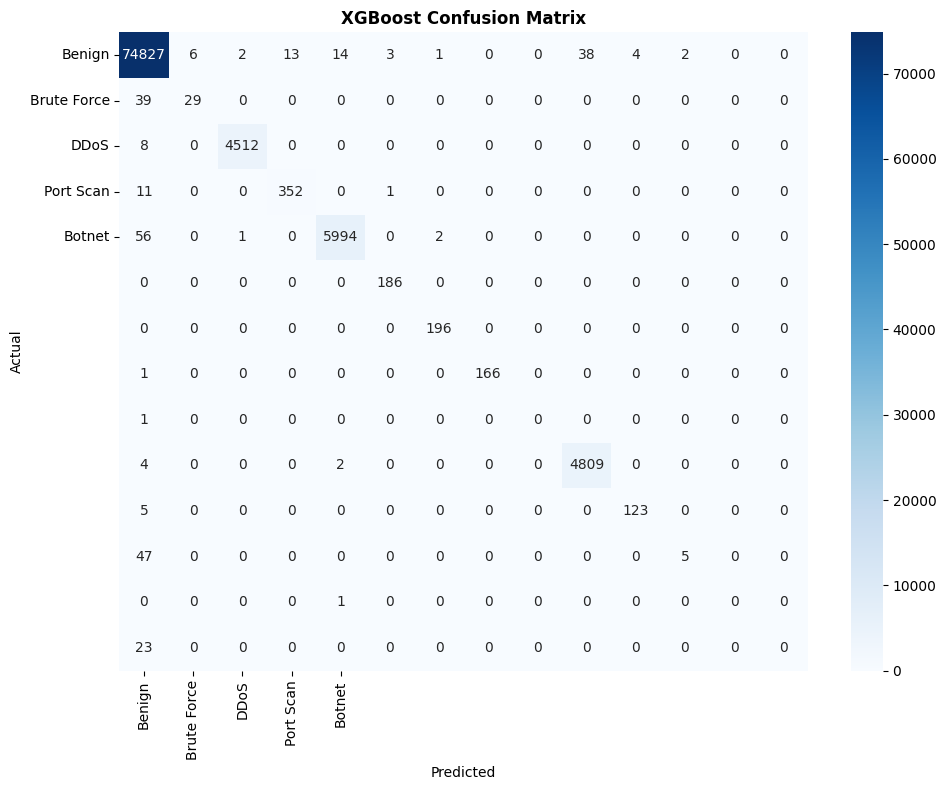


✅ Evaluation complete


In [6]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
attack_types = ['Benign', 'Brute Force', 'DDoS', 'Port Scan', 'Botnet']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=attack_types, yticklabels=attack_types)
ax.set_title('XGBoost Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\n✅ Evaluation complete")

## 4. Feature Importance


🎯 FEATURE IMPORTANCE (Top 10)
                    feature  importance
     Bwd Packet Length Mean    0.315651
     Fwd Packet Length Mean    0.116137
Total Length of Bwd Packets    0.111405
        Average Packet Size    0.110815
Total Length of Fwd Packets    0.087329
     Total Backward Packets    0.065408
               Flow Bytes/s    0.065034
               Bwd IAT Mean    0.034382
           Destination Port    0.029136
          Total Fwd Packets    0.014847


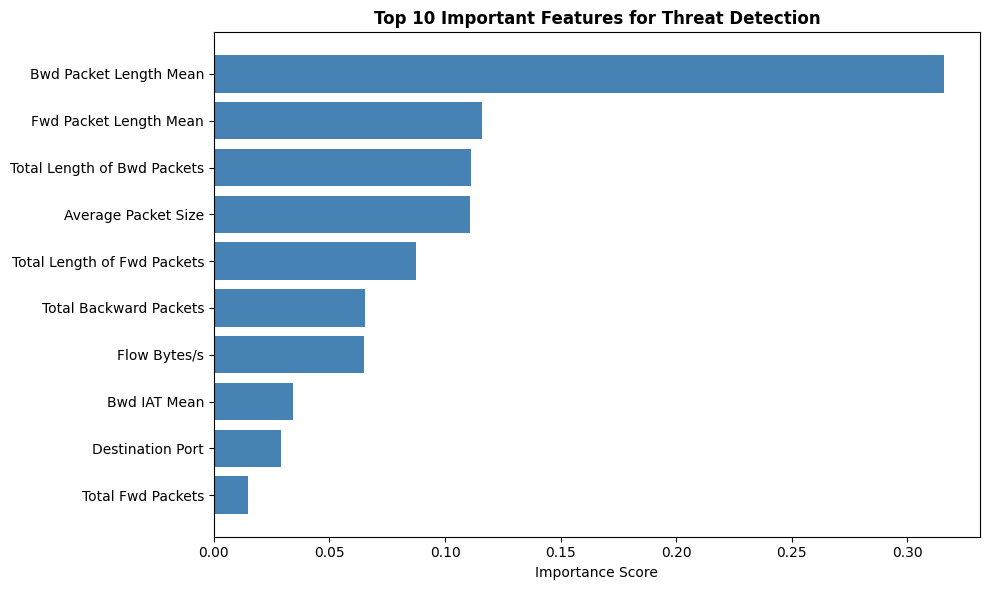

In [7]:
# Get feature importance
feature_importance = xgb_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n🎯 FEATURE IMPORTANCE (Top 10)")
print("=" * 80)
print(importance_df.head(10).to_string(index=False))

# Visualize top 10 features
fig, ax = plt.subplots(figsize=(10, 6))
top_features = importance_df.head(10)
ax.barh(top_features['feature'], top_features['importance'], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Important Features for Threat Detection', fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Save Model and Metrics

In [8]:
import os

print("\n💾 SAVING MODEL AND METRICS")
print("=" * 80)

# Create trained_models directory if it doesn't exist
os.makedirs('../trained_models', exist_ok=True)

# Save model
joblib.dump(xgb_model, '../trained_models/xgboost_model.pkl')
print(f"\n1. Saved XGBoost model:")
print(f"   xgboost_model.pkl")

# Save metrics
metrics = {
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc),
    'training_time': float(training_time),
    'test_samples': int(len(y_test)),
    'model_type': 'XGBoost Gradient Boosting',
    'num_classes': 5,
    'feature_count': int(X_train.shape[1])
}

with open('../trained_models/xgboost_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"\n2. Saved metrics:")
print(f"   xgboost_metrics.json")
print(f"   {metrics}")

print(f"\n✅ XGBoost training complete!")
print(f"\nNext: Run 03_bert.ipynb for transformer training")


💾 SAVING MODEL AND METRICS

1. Saved XGBoost model:
   xgboost_model.pkl


NameError: name 'roc_auc' is not defined